# 국회본회의 회의록 데이터에 대한 Change point model

- 제 1대 국회 - 제 21대 국회의 본회의 회의록의 발언 텍스트를 문단별로 전처리한 데이터
    - conf_num: 회의번호
    - words: 정제된 발언 텍스트의 단어
    - dae: 대 (1대-21대)
    - date: 회의 일자 
    - year: 회의 년
    - month: 회의 월
    - yearmonth: 회의 연-월
- 특정 단어의 언급량이 시간의 흐름에 따라 어떻게 달라지는가? 
- 특정 단어의 언급량이 급격히 달라진 시점이 언제인가? 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import pymc as pm 
from tqdm.auto import tqdm
import arviz as az

data_path = '../data/'
output_path = './output/'

In [2]:
# 데이터 불러오기
data = pd.read_pickle('data_national_assembly.pckl')

In [3]:
data.head()

,conf_num,words,dae,date,year,month,yearmonth
0,000002,"[국회, 회의, 시작, 국기, 경례, 순국선열, 묵념]",1,1948-06-01,1948,6,1948-06
1,000002,"[회의, 개회, 자리, 정돈, 사건, 계속, 회의록, 통과, 회의록, 낭독]",1,1948-06-01,1948,6,1948-06
2,000002,"[회의록, 낭독, 접수]",1,1948-06-01,1948,6,1948-06
3,000002,"[회의록, 동의, 사람, 배헌, 재청, 사람, 김준연, 생각, 기록, 장래, 주의]",1,1948-06-01,1948,6,1948-06
4,000002,"[교정, 동의, 이름, 교정, 자리, 좌석, 말씀, 이유, 설명, 구절, 말씀, 마...",1,1948-06-01,1948,6,1948-06


In [4]:
# 언급량을 체크하고자 하는 단어 리스트 
check_words = ['참사','국가책임','추모','재난']
data['cnt_check_words'] = 0

In [5]:
# words의 리스트가 포함하는 check_words의 개수 계산
for i, words in tqdm(enumerate(data.words), total = len(data.words)):
    data.loc[i, 'cnt_check_words']=sum([x in check_words for x in words])

  0%|          | 0/441573 [00:00<?, ?it/s]

In [6]:
# 연간 check_words 단어의 언급빈도의 합 집계
data_year = pd.DataFrame()
data_year['cnt'] = data.groupby('year').cnt_check_words.sum()

In [7]:
data_year = data_year.reset_index()

In [8]:
data_year.head()

,year,cnt
0,1948,21
1,1949,21
2,1950,20
3,1951,8
4,1952,5


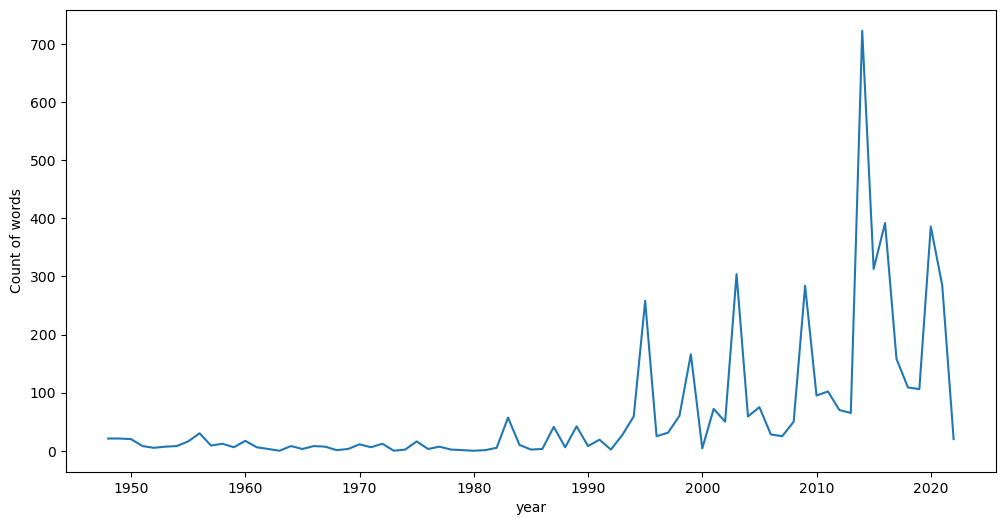

In [9]:
fig, ax = plt.subplots(1,1, figsize=(12,6))
sns.lineplot(x="year", y="cnt", data=data_year, ax=ax)
ax.set_ylabel('Count of words')
plt.show()

## One change point



$$ y_t| \lambda \sim Pos(\lambda)$$
$$\lambda = \left\{
\begin{matrix}
\lambda_1 & \mbox{if } t<\theta\\
\lambda_2 & \mbox{if } t\geq\theta\\
\end{matrix}
\right. $$ 
$$ \lambda_1 \sim exp(\alpha) $$ 
$$ \lambda_2 \sim exp(\alpha)$$
$$ \theta\sim \mathrm{DiscreteUniform(1,N)}$$
- $\frac{1}{N} \sum_{t} y_t \approx E[\lambda |\alpha ] = \frac{1}{\alpha}$

# 1

In [13]:
n_count_data = np.array(data_year.shape[0])

In [14]:
with pm.Model() as model1:
    alpha = 1.0/data_year.cnt.mean()  
                                   
    lambda_1_e1 = pm.Exponential("lambda_1_e1", alpha)
    lambda_2_e1 = pm.Exponential("lambda_2_e1", alpha)
    
    theta = pm.DiscreteUniform("theta", lower=1, upper=n_count_data-1)

    idx = np.arange(n_count_data) # Index
    lambda_ = pm.math.switch(theta > idx, lambda_1_e1, lambda_2_e1)

    observation = pm.Poisson("obs", lambda_, observed=data_year.cnt)
    trace1 = pm.sample(10000, tune=1000, chains=4, random_seed=1,
                       idata_kwargs = {"log_likelihood": True})

C:\Users\touch\anaconda3\Lib\site-packages\pytensor\link\c\cmodule.py:2959: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [lambda_1_e1, lambda_2_e1]
>Metropolis: [theta]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 64 seconds.
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


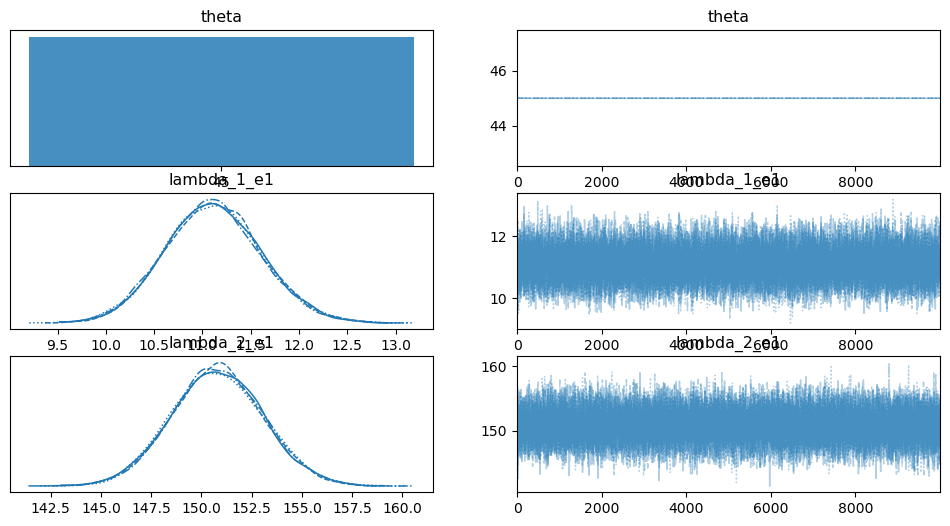

In [15]:
az.plot_trace(trace1)
plt.show()

In [16]:
trace1_sample = az.extract(trace1)

In [17]:
# 빈도계산
print(stats.mode(trace1_sample.theta))
print()
# 평균계산
mean_theta = np.mean(trace1_sample.theta)
print("평균 theta:", mean_theta)
print()
# 최다 언급 및 년도
max_cnt = data_year['cnt'].max()
year_max = data_year.loc[data_year['cnt'].idxmax(), 'year']
print(f"최다 언급량: {max_cnt} (년도: {year_max})")

ModeResult(mode=45, count=40000)

평균 theta: <xarray.DataArray 'theta' ()> Size: 8B
array(45.)

최다 언급량: 723 (년도: 2014)


In [18]:
data_year.iloc[46,:]

year    1995
cnt      258
Name: 46, dtype: int64

In [19]:
data_year.iloc[46,:]

year    1995
cnt      258
Name: 46, dtype: int64

In [20]:
data_year.iloc[46,:]

year    1995
cnt      258
Name: 46, dtype: int64

In [21]:
# save trace: az.from_netcdf()로 reload 가능
az.to_netcdf(trace1, "trace1.nc")

'trace1.nc'

In [22]:
az.summary(trace1) # trace의 여러 수치 나옴

C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,45.000,0.000,45.000,45.000,0.000,NaN,40000.0,40000.0,NaN
lambda_1_e1,11.109,0.496,10.174,12.040,0.003,0.002,39183.0,28206.0,1.0
lambda_2_e1,150.791,2.279,146.456,155.037,0.011,0.011,39330.0,29653.0,1.0


# 2
## 사전분포 및 모수 변경
### Lambda 사전분포: Exponential -> Gamma
### 모수 : alpha = 5, beta = 0.05

In [24]:
data_year.cnt.mean()

65.85135135135135

In [25]:
with pm.Model() as model2:
    alpha = 5
    beta = 0.05
    lambda_1_g1 = pm.Gamma("lambda_1_g1", alpha, beta)
    lambda_2_g1 = pm.Gamma("lambda_2_g1", alpha, beta)

    theta = pm.DiscreteUniform("theta", lower=1, upper=n_count_data-1)

    idx = np.arange(n_count_data)
    lambda_ = pm.math.switch(theta > idx, lambda_1_g1, lambda_2_g1)

    observation = pm.Poisson("obs", lambda_, observed=data_year.cnt)

    trace2 = pm.sample(10000, tune=1000, chains=4, random_seed=1,
                       idata_kwargs={"log_likelihood": True})

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [lambda_1_g1, lambda_2_g1]
>Metropolis: [theta]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 66 seconds.
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


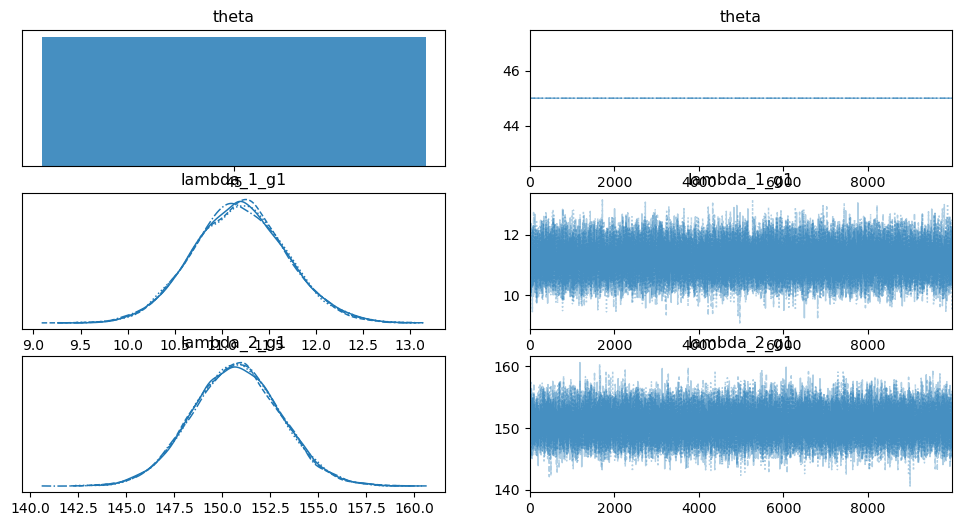

In [26]:
az.plot_trace(trace2)
plt.show()

In [27]:
# save trace: az.from_netcdf()로 reload 가능
az.to_netcdf(trace2, "trace2.nc")

'trace2.nc'

In [28]:
trace2_sample = az.extract(trace2)

In [29]:
# 빈도계산
print(stats.mode(trace2_sample.theta))
print()
# 평균계산
mean_theta = np.mean(trace2_sample.theta)
print("평균 theta:", mean_theta)
print()
# 최다 언급 및 년도
max_cnt = data_year['cnt'].max()
year_max = data_year.loc[data_year['cnt'].idxmax(), 'year']
print(f"최다 언급량: {max_cnt} (년도: {year_max})")

ModeResult(mode=45, count=40000)

평균 theta: <xarray.DataArray 'theta' ()> Size: 8B
array(45.)

최다 언급량: 723 (년도: 2014)


In [150]:
data_year.iloc[45,:]

year    1994
cnt       59
Name: 45, dtype: int64

In [30]:
az.summary(trace2) # trace의 여러 수치 나옴

C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,45.000,0.000,45.000,45.000,0.000,NaN,40000.0,40000.0,NaN
lambda_1_g1,11.189,0.498,10.259,12.132,0.002,0.002,41548.0,29753.0,1.0
lambda_2_g1,150.737,2.300,146.390,155.021,0.011,0.012,42844.0,30256.0,1.0


## Two change points
- Priors
    $$ y_t| \lambda \sim Pos(\lambda)$$
    $$\lambda|\tau_1, \tau_2, \alpha = \left\{
\begin{matrix}
\lambda_1 & \mbox{if } t<\theta_1\\
\lambda_2 & \mbox{if } \theta_1 \leq t <\theta_2\\
\lambda_3 & \mbox{if } t\geq \theta_2\\
\end{matrix}
\right. $$ 
    $$ \lambda_1 |\alpha\sim exp(\alpha) $$ 
    $$ \lambda_2 |\alpha\sim exp(\alpha)$$
     $$ \lambda_3 |\alpha\sim exp(\alpha)$$

    $$ \theta_1\sim \mathrm{DiscreteUniform(1,N-1)}$$
    $$ \theta_2\sim \mathrm{DiscreteUniform(\theta_1,N)}$$

     - $\frac{1}{N} \sum_{t} y_t \approx E[\lambda |\alpha ] = \frac{1}{\alpha}$
    

# 3

In [33]:
with pm.Model() as model3:
    alpha = 1.0/data_year.cnt.mean() 

    lambda_1_e2 = pm.Exponential("lambda_1_e2", alpha)
    lambda_2_e2 = pm.Exponential("lambda_2_e2", alpha)
    lambda_3_e2 = pm.Exponential("lambda_3_e2", alpha)
   
    theta_1_e2 = pm.DiscreteUniform("theta_1_e2", lower=0, upper=n_count_data - 2)
    theta_2_e2 = pm.DiscreteUniform("theta_2_e2", lower=theta_1_e2, upper=n_count_data - 1)

    idx = np.arange(n_count_data) # Index
    lambda_ = pm.math.switch(theta_2_e2 > idx, 
                             pm.math.switch(theta_1_e2 > idx, 
                                            lambda_1_e2, lambda_2_e2), lambda_3_e2)
    observation = pm.Poisson("obs", lambda_, observed=data_year.cnt)
    trace3 = pm.sample(10000, tune=1000, chains=4, random_seed=1, idata_kwargs = {"log_likelihood": True}, progressbar=False)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [lambda_1_e2, lambda_2_e2, lambda_3_e2]
>CompoundStep
>>Metropolis: [theta_1_e2]
>>Metropolis: [theta_2_e2]
Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 63 seconds.
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


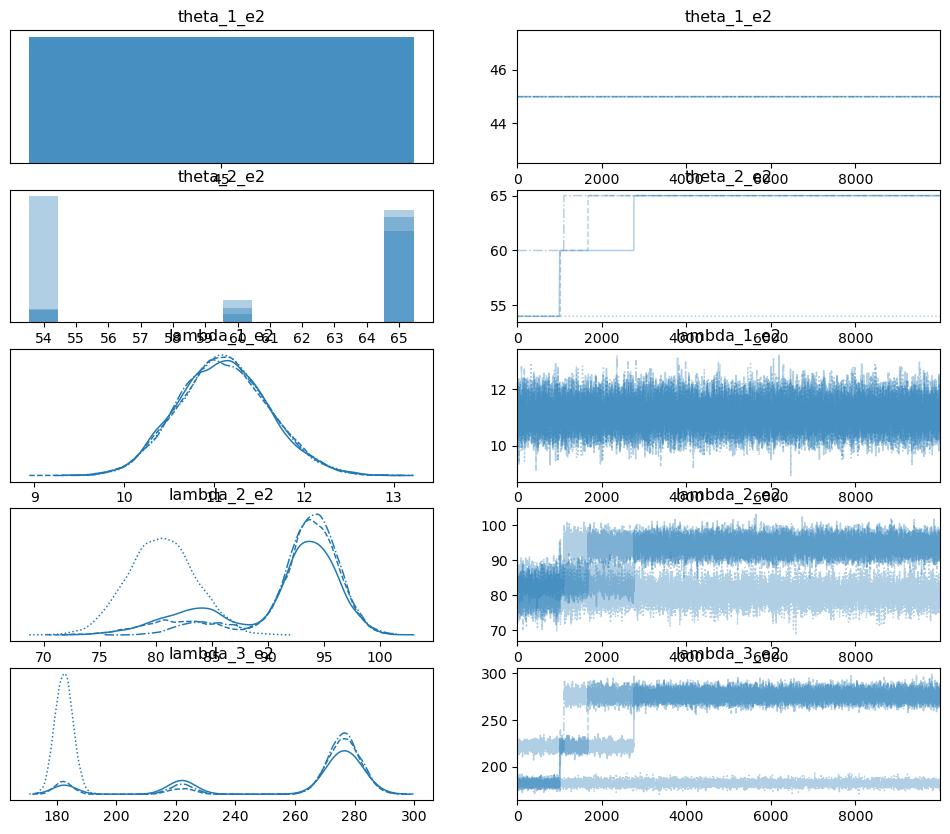

In [34]:
az.plot_trace(trace3)
plt.show()

In [35]:
# save trace: az.from_netcdf()로 reload 가능
az.to_netcdf(trace3, "trace3.nc")

'trace3.nc'

In [36]:
trace3_sample = az.extract(trace3)

In [37]:
theta1_e2 = stats.mode(trace3_sample.theta_1_e2)
theta2_e2 = stats.mode(trace3_sample.theta_2_e2)

In [38]:
theta1_e2, theta2_e2

(ModeResult(mode=45, count=40000), ModeResult(mode=65, count=24464))

In [39]:
data_year.iloc[[theta1_e2[0], theta2_e2[0]],:] 

,year,cnt
45,1994,59
65,2014,723


In [40]:
az.summary(trace3)

C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_1_e2,45.000,0.000,45.000,45.000,0.000,NaN,40000.0,40000.0,NaN
theta_2_e2,61.256,4.953,54.000,65.000,2.221,0.833,5.0,5.0,2.18
lambda_1_e2,11.105,0.502,10.154,12.028,0.003,0.003,34684.0,26314.0,1.00
lambda_2_e2,89.164,6.737,77.123,98.123,2.737,0.875,8.0,40.0,1.43
lambda_3_e2,243.460,43.075,178.273,285.363,18.940,6.467,8.0,39.0,1.47


# 4
## 사전분포 및 모수 변경
### Lambda 사전분포: Exponential -> Gamma
### 모수 : alpha = 5, beta = 0.05

In [42]:
with pm.Model() as model4:
    alpha = 5
    beta = 0.05

    lambda_1_g2 = pm.Gamma("lambda_1_g2", alpha, beta)
    lambda_2_g2 = pm.Gamma("lambda_2_g2", alpha, beta)
    lambda_3_g2 = pm.Gamma("lambda_3_g2", alpha, beta)
   
    theta_1_g2 = pm.DiscreteUniform("theta_1_g2", lower=0, upper=n_count_data - 2)
    theta_2_g2 = pm.DiscreteUniform("theta_2_g2", lower=theta_1_g2, upper=n_count_data - 1)

    idx = np.arange(n_count_data) # Index
    lambda_ = pm.math.switch(theta_2_g2 > idx, 
                             pm.math.switch(theta_1_g2 > idx, 
                                            lambda_1_g2, lambda_2_g2), lambda_3_g2)
    observation = pm.Poisson("obs", lambda_, observed=data_year.cnt)
    trace4 = pm.sample(10000, tune=1000, chains=4, random_seed=1, idata_kwargs = {"log_likelihood": True}, progressbar=False)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [lambda_1_g2, lambda_2_g2, lambda_3_g2]
>CompoundStep
>>Metropolis: [theta_1_g2]
>>Metropolis: [theta_2_g2]
Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 64 seconds.
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


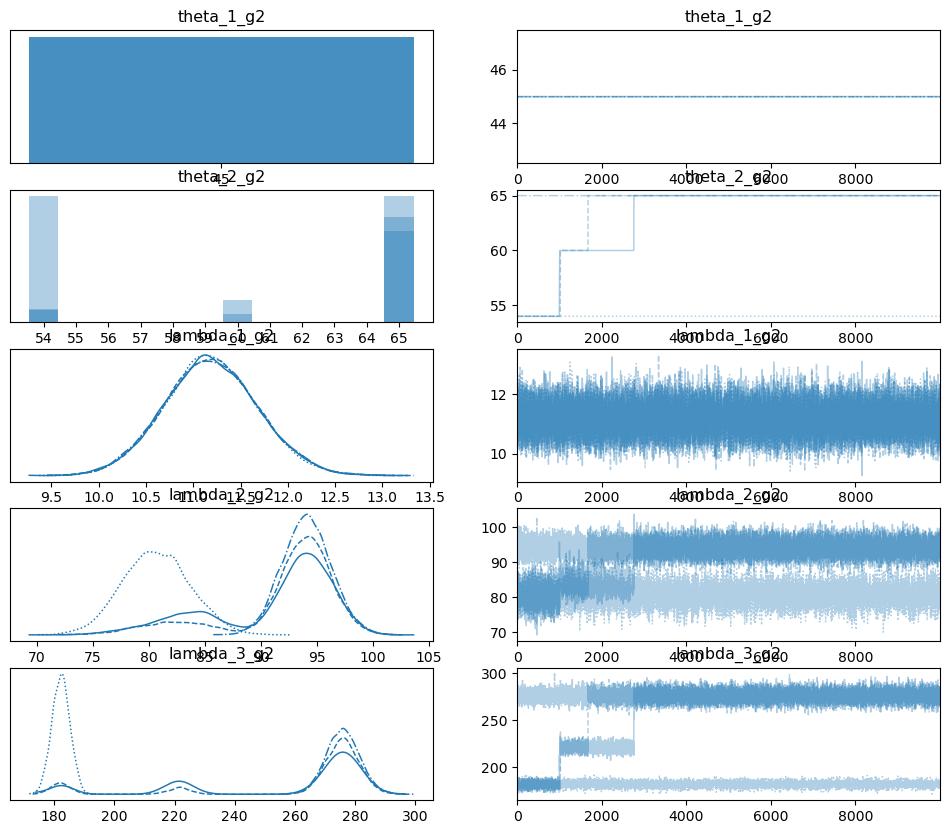

In [43]:
az.plot_trace(trace4)
plt.show()

In [44]:
# save trace: az.from_netcdf()로 reload 가능
az.to_netcdf(trace4, "trace4.nc")

'trace4.nc'

In [45]:
trace4_sample = az.extract(trace4)

In [46]:
theta1_g2 = stats.mode(trace4_sample.theta_1_g2)
theta2_g2 = stats.mode(trace4_sample.theta_2_g2)

In [47]:
theta1_g2, theta2_g2

(ModeResult(mode=45, count=40000), ModeResult(mode=65, count=25566))

In [48]:
data_year.iloc[[theta1_g2[0], theta2_g2[0]],:] 

,year,cnt
45,1994,59
65,2014,723


In [49]:
az.summary(trace4) # trace의 여러 수치 나옴

C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_1_g2,45.000,0.000,45.000,45.000,0.000,NaN,40000.0,40000.0,NaN
theta_2_g2,61.394,4.985,54.000,65.000,2.267,0.877,5.0,5.0,2.38
lambda_1_g2,11.187,0.492,10.267,12.125,0.002,0.002,42901.0,29709.0,1.00
lambda_2_g2,89.498,6.682,77.054,97.933,2.792,0.971,8.0,40.0,1.45
lambda_3_g2,244.474,43.033,177.882,284.662,19.341,6.998,7.0,42.0,1.48


## Three change points

# 5

In [52]:
with pm.Model() as model5:
    alpha = 1.0/data_year.cnt.mean() 

    lambda_1_e3 = pm.Exponential("lambda_1_e3", alpha)
    lambda_2_e3 = pm.Exponential("lambda_2_e3", alpha)
    lambda_3_e3 = pm.Exponential("lambda_3_e3", alpha)
    lambda_4_e3 = pm.Exponential("lambda_4_e3", alpha)
    
   
    theta_1_e3 = pm.DiscreteUniform("theta_1_e3", lower=0, upper=n_count_data - 3)
    theta_2_e3 = pm.DiscreteUniform("theta_2_e3", lower=theta_1_e3 + 1, upper=n_count_data - 2)
    theta_3_e3 = pm.DiscreteUniform("theta_3_e3", lower=theta_2_e3 + 1, upper=n_count_data - 1)

    idx = np.arange(n_count_data) # Index
    lambda_ = pm.math.switch(
        idx < theta_1_e3,lambda_1_e3,
        pm.math.switch(
            idx < theta_2_e3,lambda_2_e3,
            pm.math.switch(
                idx < theta_3_e3,lambda_3_e3,lambda_4_e3)))
    observation = pm.Poisson("obs", lambda_, observed=data_year.cnt)
    trace5 = pm.sample(10000, tune=1000, chains=4, random_seed=1, idata_kwargs = {"log_likelihood": True}, progressbar=False)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [lambda_1_e3, lambda_2_e3, lambda_3_e3, lambda_4_e3]
>CompoundStep
>>Metropolis: [theta_1_e3]
>>Metropolis: [theta_2_e3]
>>Metropolis: [theta_3_e3]
Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 72 seconds.
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


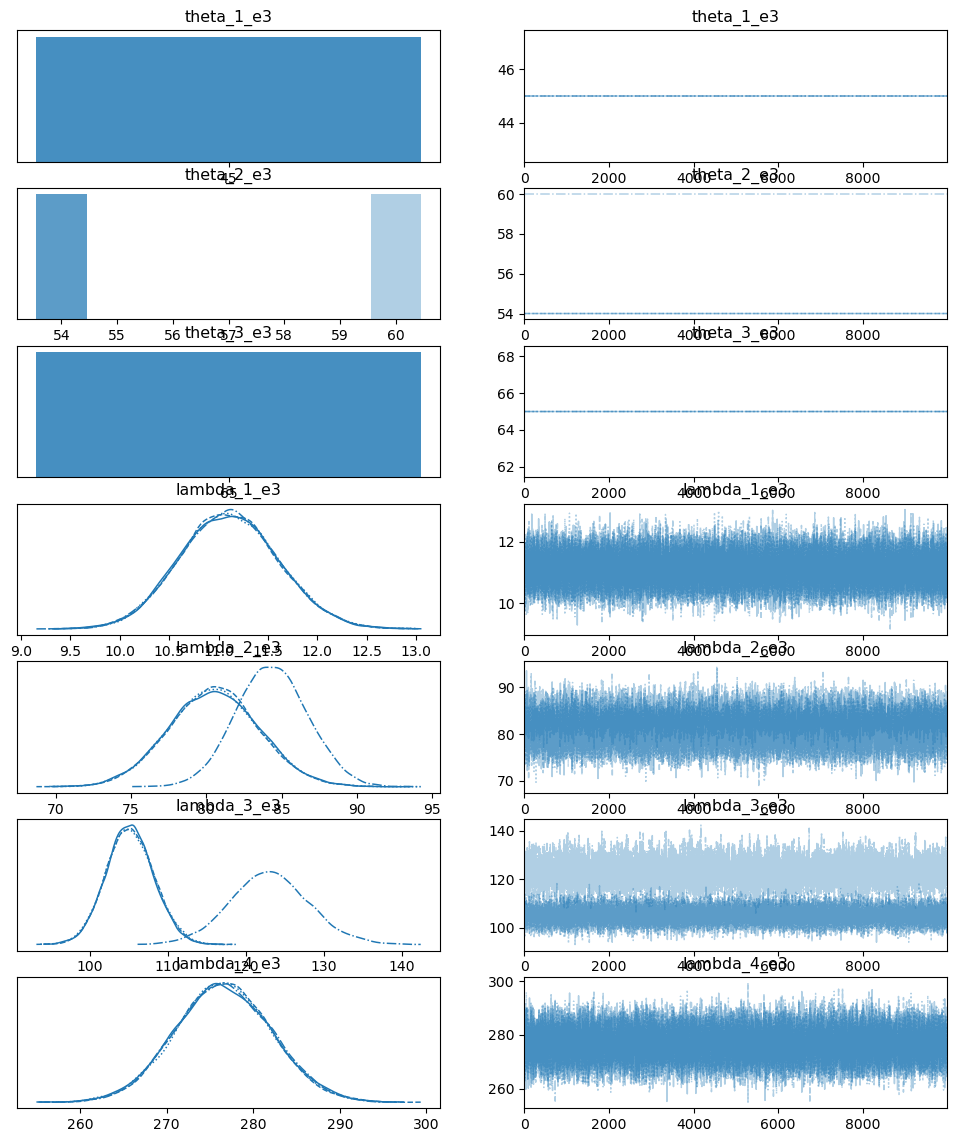

In [53]:
az.plot_trace(trace5)
plt.show()

In [54]:
# save trace: az.from_netcdf()로 reload 가능
az.to_netcdf(trace5, "trace5.nc")

'trace5.nc'

In [55]:
trace5_sample = az.extract(trace5)

In [56]:
theta1_e3 = stats.mode(trace5_sample.theta_1_e3)
theta2_e3 = stats.mode(trace5_sample.theta_2_e3)

In [57]:
theta1_e3, theta2_e3

(ModeResult(mode=45, count=40000), ModeResult(mode=54, count=30000))

In [58]:
data_year.iloc[[theta1_e3[0], theta2_e3[0]],:] 

,year,cnt
45,1994,59
54,2003,304


In [59]:
az.summary(trace5) # trace의 여러 수치 나옴

C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_1_e3,45.000,0.000,45.000,45.000,0.000,NaN,40000.0,40000.0,NaN
theta_2_e3,55.500,2.598,54.000,60.000,1.299,0.750,4.0,4.0,2436672.09
theta_3_e3,65.000,0.000,65.000,65.000,0.000,NaN,40000.0,40000.0,NaN
lambda_1_e3,11.108,0.497,10.177,12.040,0.002,0.002,67940.0,33398.0,1.00
lambda_2_e3,81.490,3.297,75.390,87.648,0.861,0.091,15.0,68.0,1.18
lambda_3_e3,109.623,8.567,98.995,127.622,3.913,2.280,7.0,25.0,1.52
lambda_4_e3,276.530,5.540,266.150,286.976,0.022,0.027,60798.0,32736.0,1.00


# 6
## 사전분포 및 모수 변경
### Lambda 사전분포: Exponential -> Gamma
### 모수 : alpha = 5, beta = 0.05

In [62]:
with pm.Model() as model5:
    alpha = 5
    beta = 0.05

    lambda_1_g3 = pm.Gamma("lambda_1_g3", alpha, beta)
    lambda_2_g3 = pm.Gamma("lambda_2_g3", alpha, beta)
    lambda_3_g3 = pm.Gamma("lambda_3_g3", alpha, beta)
    lambda_4_g3 = pm.Gamma("lambda_4_g3", alpha, beta)
    
    theta_1_g3 = pm.DiscreteUniform("theta_1_g3", lower=0, upper=n_count_data - 3)
    theta_2_g3 = pm.DiscreteUniform("theta_2_g3", lower=theta_1_g3 + 1, upper=n_count_data - 2)
    theta_3_g3 = pm.DiscreteUniform("theta_3_g3", lower=theta_2_g3 + 1, upper=n_count_data - 1)

    idx = np.arange(n_count_data) # Index
    lambda_ = pm.math.switch(
        idx < theta_1_g3,lambda_1_g3,
        pm.math.switch(
            idx < theta_2_g3,lambda_2_g3,
            pm.math.switch(
                idx < theta_3_g3,lambda_3_g3,lambda_4_g3)))
    observation = pm.Poisson("obs", lambda_, observed=data_year.cnt)
    trace6 = pm.sample(10000, tune=1000, chains=4, random_seed=1, idata_kwargs = {"log_likelihood": True}, progressbar=False)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [lambda_1_g3, lambda_2_g3, lambda_3_g3, lambda_4_g3]
>CompoundStep
>>Metropolis: [theta_1_g3]
>>Metropolis: [theta_2_g3]
>>Metropolis: [theta_3_g3]
Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 74 seconds.
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


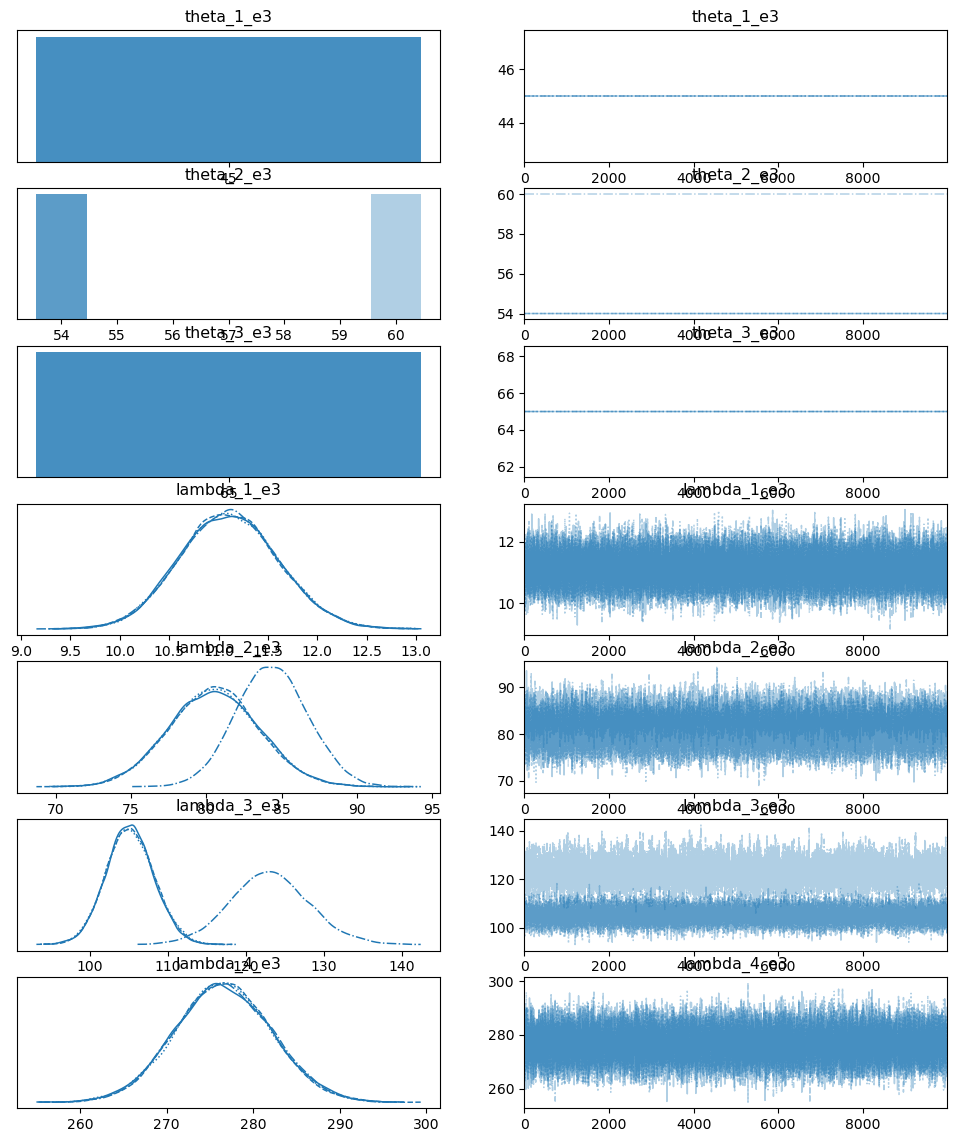

In [63]:
az.plot_trace(trace5)
plt.show()

In [64]:
# save trace: az.from_netcdf()로 reload 가능
az.to_netcdf(trace6, "trace6.nc")

'trace6.nc'

In [65]:
trace6_sample = az.extract(trace6)

In [66]:
theta1_g3 = stats.mode(trace6_sample.theta_1_g3)
theta2_g3 = stats.mode(trace6_sample.theta_2_g3)

In [67]:
theta1_g3, theta2_g3

(ModeResult(mode=45, count=40000), ModeResult(mode=54, count=30000))

In [68]:
data_year.iloc[[theta1_e3[0], theta2_g3[0]],:] 

,year,cnt
45,1994,59
54,2003,304


In [69]:
az.summary(trace6) # trace의 여러 수치 나옴

C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_1_g3,45.000,0.000,45.000,45.000,0.000,NaN,40000.0,40000.0,NaN
theta_2_g3,55.500,2.598,54.000,60.000,1.299,0.750,4.0,4.0,2436672.09
theta_3_g3,65.000,0.000,65.000,65.000,0.000,NaN,40000.0,40000.0,NaN
lambda_1_g3,11.187,0.498,10.223,12.097,0.002,0.003,65818.0,30981.0,1.00
lambda_2_g3,81.609,3.278,75.430,87.563,0.851,0.016,15.0,75.0,1.17
lambda_3_g3,109.620,8.537,98.774,127.313,3.902,2.258,7.0,26.0,1.52
lambda_4_g3,275.956,5.536,265.500,286.343,0.022,0.029,60630.0,30586.0,1.00


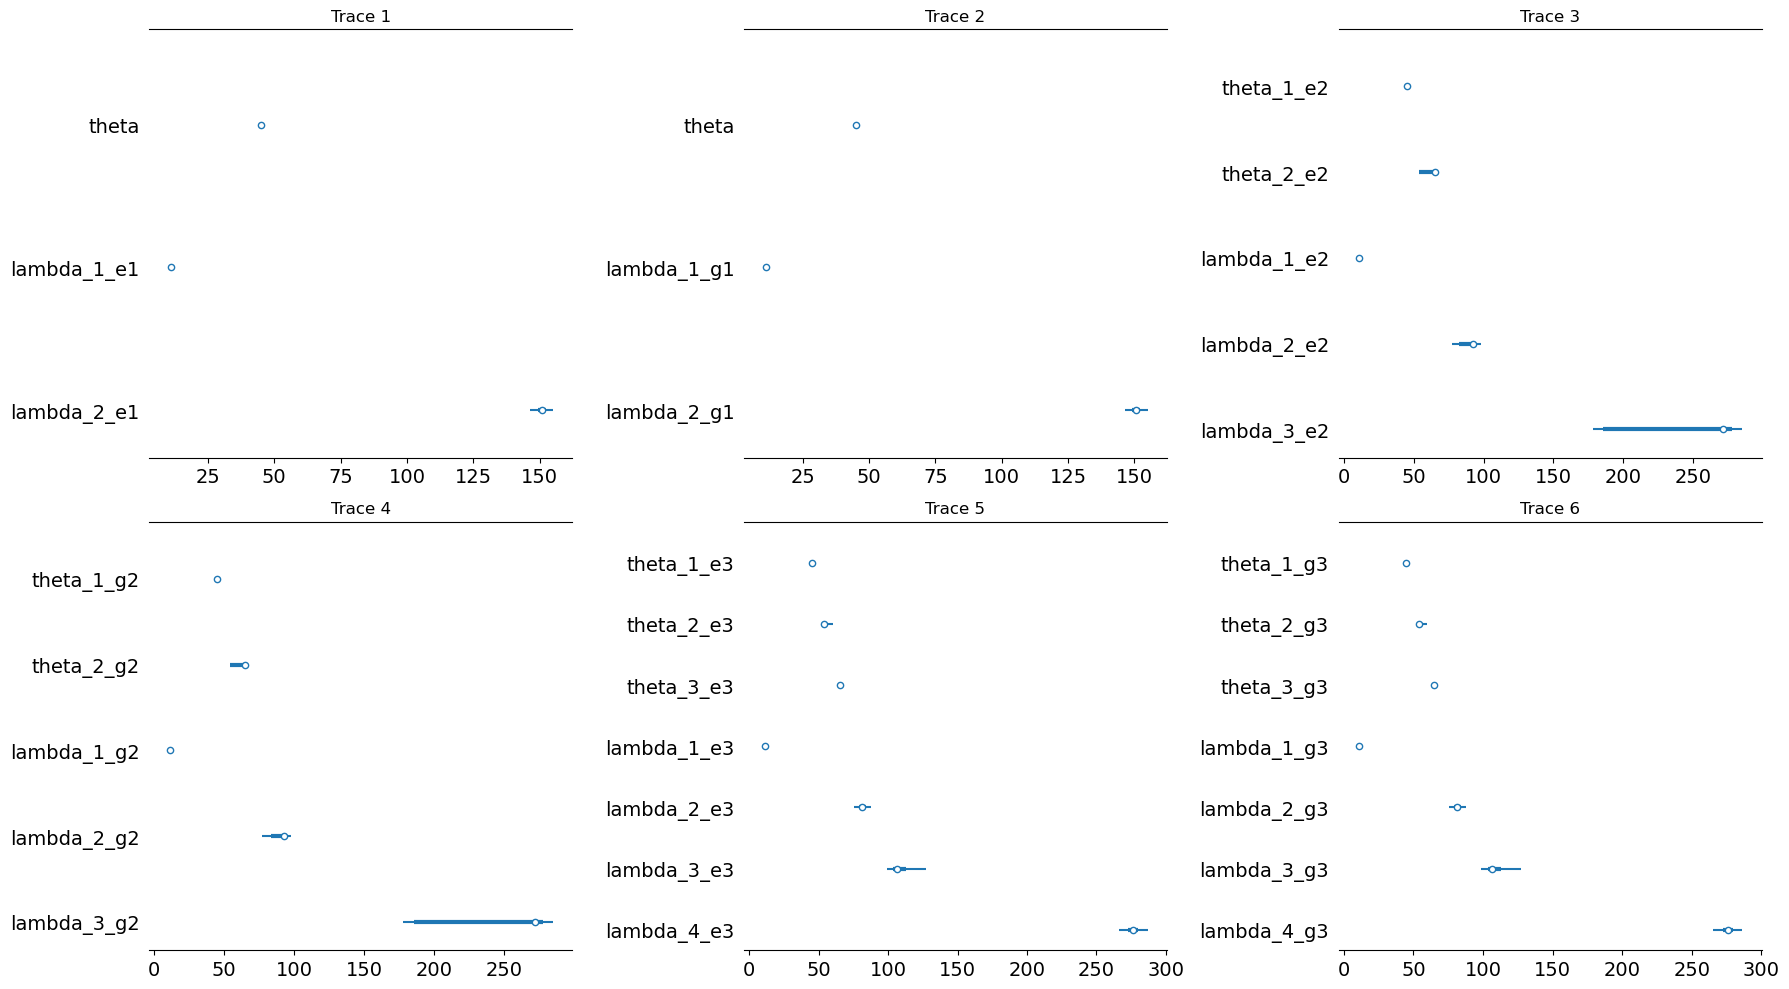

In [70]:
import matplotlib.pyplot as plt
import arviz as az

# trace 리스트 (각 trace는 이미 샘플링 완료된 상태여야 함)
traces = [trace1, trace2, trace3, trace4, trace5, trace6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, ax in enumerate(axes.flatten()):
    az.plot_forest(traces[i], ax=ax, combined=True)
    ax.set_title(f"Trace {i+1}")

plt.tight_layout()
plt.show()

## Model Comparison 각 모델들 비교해줌
https://python.arviz.org/en/stable/api/generated/arviz.compare.html

In [72]:
result = az.compare({"model1": trace1, "model2":trace2, "model3": trace3, "model4":trace4, "model5": trace5, "model6":trace6}) 

C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
C:\Users\touch\anaconda3\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. Y

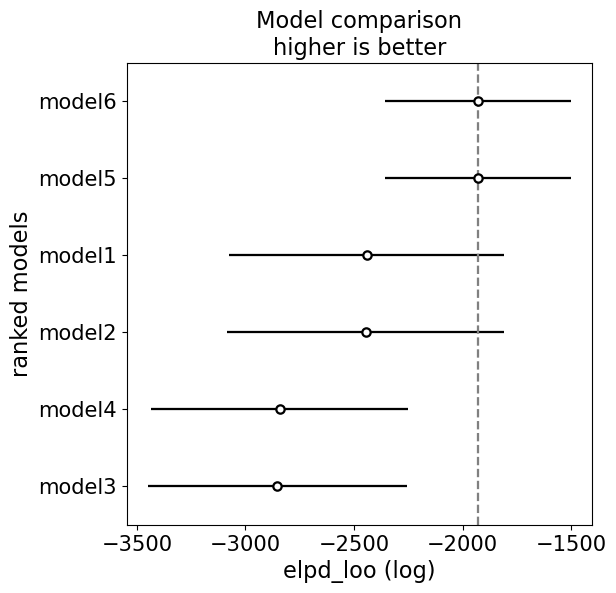

In [73]:
az.plot_compare(result)
plt.show()

In [134]:
lambda_1 = trace2_sample.lambda_1_g1.mean()
lambda_2 = trace2_sample.lambda_2_g1.mean()

In [136]:
lambda_1, lambda_2

(<xarray.DataArray 'lambda_1_g1' ()> Size: 8B
 array(11.18885761),
 <xarray.DataArray 'lambda_2_g1' ()> Size: 8B
 array(150.73654571))

In [140]:
theta = stats.mode(trace2_sample.theta)[0]

In [144]:
theta

45

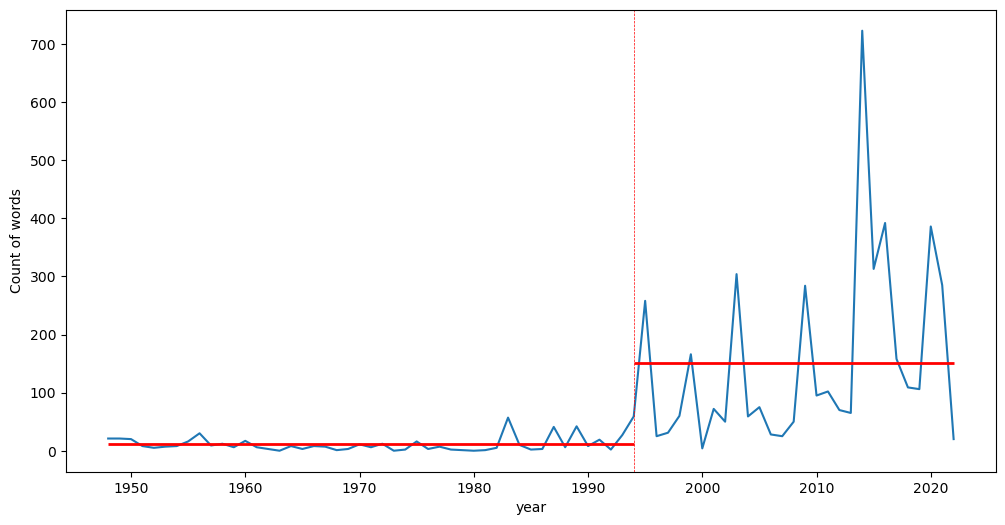

In [148]:
fig, ax = plt.subplots(1,1, figsize=(12,6))
sns.lineplot(x="year", y="cnt", data=data_year, ax=ax)
ax.set_ylabel('Count of words')
plt.axvline(x=data_year.iloc[theta,:]["year"], color='r',ls='--', lw=0.5)
plt.hlines(y=lambda_1, xmin = data_year.year.iloc[0], xmax = data_year.iloc[theta,:]["year"], 
         colors = 'red', linewidth=2 )
plt.hlines(y=lambda_2, xmin = data_year.iloc[theta,:]["year"], 
           xmax = data_year.year.iloc[-1], 
         colors = 'red', linewidth=2 )
plt.show()


## <font color='blue'> TO DO: (제출기한 5/22 목요일)

- <font color='blue'>관심있는 주제의 단어 리스트를 작성하시오.
- <font color='blue'>국회본회의에서 해당 단어가 언급된 빈도를 계산하시오.
- <font color='blue'>그 빈도가 급격하게 변한 시점을 Bayesian Change Point Model을 사용하여 탐색하시오.
  - 몇 개의 change point가 적당할까?
  - prior distribution을 어떻게 변화시킬 수 있을까?
  - prior distibution의 모수를 어떻게 결정할까?
    
#### [제출파일 1: 분석 보고서]
-  A4 2페이지 이내로 아래 내용이 포함되게 정리하여 pdf 파일로 제출
    - 비교 모형들에 대한 요약
    - 최종 모형에 대한 설명과 이를 기반으로 한 모수추정치
    - 해당 시기에 어떤 관련 이벤트가 있었는가를 조사하여 모형 해석
      
#### [제출파일 2: 첨부자료]
- 분석 보고서를 도출하기 위한 모델링 과정을 확인할 수 있는 .ipynb 파일을 html로 변환하여 제출
